##  Этап 0: Импорт библиотек

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna

from itertools import product
from tqdm import tqdm
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GroupKFold,
    StratifiedKFold,
    TimeSeriesSplit,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.feature_selection import (
    SelectKBest,
    f_regression,
    chi2,
    mutual_info_regression
)
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning 
from sklearn.preprocessing import LabelEncoder

# Настройки
warnings.filterwarnings('ignore', category=ConvergenceWarning)

### Этап 1: Ответы на теоретические вопросы

####  Вопрос 1.1: Что такое Leave-One-Out (LOO) кросс-валидация?

**Определение:**  
Leave-One-Out — это предельный случай $k$-fold кросс-валидации, где число фолдов $k$ равно количеству наблюдений $N$ в выборке. На каждой из $N$ итераций модель обучается на $N-1$ наблюдениях, а одно оставшееся наблюдение используется для валидации. Итоговая метрика вычисляется как среднее арифметическое по всем $N$ итерациям.

** Сильные стороны:**
- **Максимальное использование данных:** на каждом шаге модель видит почти всю выборку, что снижает смещение (bias) оценки качества.
- **Детерминированность:** результат не зависит от случайного разбиения данных (нет параметра `random_state`).
- **Полезен для малых выборок:** когда данных критически мало, LOO позволяет извлечь максимум информации.

** Ограничения:**
- **Высокая вычислительная сложность:** требуется обучить модель $N$ раз. Для $N > 10^4$ это становится непрактичным.
- **Высокая дисперсия оценки:** поскольку обучающие подвыборки на разных шагах сильно пересекаются, предсказания коррелируют, что может привести к неустойчивой оценке обобщающей способности.
- **Чувствительность к выбросам:** если в данных есть аномальные наблюдения, они поочерёдно попадают в тестовый фолд и могут сильно исказить среднюю метрику.

---

#### Вопрос 1.2: Как работают методы оптимизации гиперпараметров?

#### Grid Search (Поиск по сетке)
- **Принцип:** задаётся дискретная сетка значений для каждого гиперпараметра. Алгоритм последовательно обучает и оценивает модель на **всех возможных комбинациях** параметров.
- **Плюсы:** гарантирует нахождение оптимальной комбинации в пределах заданной сетки; прост в реализации и интерпретации.
- **Минусы:** страдает от «проклятия размерности». Время работы растёт экспоненциально с увеличением числа параметров или шага сетки.

####  Randomized Grid Search (Случайный поиск)
- **Принцип:** вместо полного перебора из заданных распределений (равномерных, логарифмических и т.д.) случайно выбирается фиксированное число комбинаций (`n_iter`).
- **Плюсы:** значительно быстрее Grid Search; эффективнее исследует высокоразмерные пространства; часто находит решения не хуже полного перебора за меньшее время.
- **Минусы:** нет гарантии покрытия всей области поиска; результат зависит от удачи и числа итераций.

####  Bayesian Optimization (Байесовская оптимизация)
- **Принцип:** строится вероятностная **суррогатная модель** (чаще всего Gaussian Process или дерево Парзена), которая аппроксимирует зависимость `метрика ~ гиперпараметры`. На основе этой модели и **функции приобретения** (Acquisition Function, например, Expected Improvement) выбирается следующая точка для вычисления, балансируя exploration (исследование новых областей) и exploitation (уточнение перспективных областей).
- **Плюсы:** требует минимального числа итераций для сходимости; учитывает результаты предыдущих запусков; идеален для дорогих «чёрных ящиков» (долгое обучение модели).
- **Минусы:** накладные расходы на обучение суррогатной модели; сложность настройки самой оптимизации; может застрять в локальных оптимумах при неудачном выборе ядра/аппроксиматора.

---

####  Вопрос 1.3: Классификация методов отбора признаков

####  Общая классификация
Методы делятся по степени взаимодействия с моделью машинного обучения:

| Тип | Принцип работы | Скорость | Точность отбора | Примеры |
|-----|----------------|----------|-----------------|---------|
| **Filter (Фильтры)** | Независимы от модели. Оценивают признаки по статистическим критериям до обучения. |  Очень быстро |  Ниже (игнорирует взаимодействие признаков с моделью) | Pearson, Chi², Mutual Information, Variance Threshold |
| **Wrapper (Обёртки)** | Используют конкретную ML-модель как «чёрный ящик» для оценки подмножеств признаков. Итеративно добавляют/удаляют признаки. |  Медленно |  Высоко (учитывает взаимодействия) | RFE, Forward/Backward Selection |
| **Embedded (Встроенные)** | Отбор происходит **в процессе обучения** модели (через регуляризацию или архитектуру). |  Средне |  Высоко | Lasso (L1), Ridge (L2), ElasticNet, Feature importance деревьев |

####  Детальное описание запрошенных методов

####  Pearson (коэффициент корреляции Пирсона)
- **Суть:** измеряет линейную зависимость между двумя непрерывными переменными. Значения лежат в диапазоне $[-1, 1]$.
- **Применение в отборе:** 
  1. Удаляются признаки с высокой корреляцией между собой ($|r| > 0.9$) для борьбы с мультиколлинеарностью.
  2. Оставляются признаки с высокой корреляцией с целевой переменной.
- **Ограничение:** улавливает только линейные зависимости.

####  Chi-Square (Хи-квадрат, $\chi^2$)
- **Суть:** статистический критерий проверки гипотезы о независимости двух категориальных переменных. Сравнивает наблюдаемые частоты с ожидаемыми при условии независимости.
- **Применение:** отбор категориальных признаков для задач классификации. Большое значение статистики $\chi^2$ (или маленькое p-value) означает сильную зависимость признака от целевой переменной.
- **Ограничение:** требует неотрицательных значений признаков; не работает с непрерывными target/feature без дискретизации.

####  Lasso (Least Absolute Shrinkage and Selection Operator)
- **Суть:** метод линейной регрессии с **L1-регуляризацией**. К функции потерь добавляется штраф, пропорциональный сумме абсолютных значений весов:  
  $$ \text{Loss} = \text{MSE} + \alpha \sum_{j=1}^{p} |w_j| $$
- **Механизм отбора:** L1-штраф «сплющивает» геометрию функции потерь до ромба. Оптимум часто попадает на вершины/рёбра, где некоторые коэффициенты становятся **строго равными нулю**. Признаки с нулевым весом автоматически исключаются из модели.
- **Плюс:** одновременно выполняет регуляризацию и отбор признаков.

####  Permutation Importance (Важность на основе перестановок)
- **Суть:** модельно-независимый метод. После обучения модели значения одного признака случайно перемешиваются (шумятся), что разрывает его связь с target. Затем измеряется падение метрики качества (например, MAE или Accuracy).
- **Интерпретация:** чем сильнее упала метрика после перемешивания, тем важнее был признак. Если метрика не изменилась — признак не нёс полезного сигнала.
- **Плюс:** учитывает нелинейные зависимости и взаимодействия; работает с любой готовой моделью.

####  SHAP (SHapley Additive exPlanations)
- **Суть:** метод, основанный на концепции **значений Шепли** из теории кооперативных игр. Рассчитывает справедливый вклад каждого признака в итоговое предсказание, учитывая все возможные комбинации признаков.
- **Применение:** 
  - **Локальная интерпретация:** почему модель выдала именно такой прогноз для конкретного объекта?
  - **Глобальная интерпретация:** усреднение абсолютных SHAP-значений по всей выборке даёт стабильную оценку важности признаков.
- **Плюсы:** строгое математическое обоснование (аддитивность, эффективность, симметрия); единая шкала для любых моделей.
- **Минусы:** вычислительно затратен для точного расчёта (используются аппроксимации: `TreeSHAP`, `KernelSHAP`, `LinearSHAP`).


## Этап 2. Загрузка и предобработка данных

#### 2.1. Загрузка данных из файла и создание датафреймов

In [2]:
pd_train = pd.read_json('data/train.json')
pd_test = pd.read_json('data/test.json')

print('Train data test info:')
print(pd_test.info())
print('Test data info:')
print(pd_test.info())

Train data test info:
<class 'pandas.core.frame.DataFrame'>
Index: 74659 entries, 0 to 124010
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        74659 non-null  float64
 1   bedrooms         74659 non-null  int64  
 2   building_id      74659 non-null  object 
 3   created          74659 non-null  object 
 4   description      74659 non-null  object 
 5   display_address  74659 non-null  object 
 6   features         74659 non-null  object 
 7   latitude         74659 non-null  float64
 8   listing_id       74659 non-null  int64  
 9   longitude        74659 non-null  float64
 10  manager_id       74659 non-null  object 
 11  photos           74659 non-null  object 
 12  price            74659 non-null  int64  
 13  street_address   74659 non-null  object 
dtypes: float64(3), int64(3), object(8)
memory usage: 8.5+ MB
None
Test data info:
<class 'pandas.core.frame.DataFrame'>
Index: 74659 ent

### 2.2 Проверка целевой переменной "Interest level" и ее предобработка

In [3]:
print('Перечень столбцов в pd_train:')
print(pd_train.columns.tolist())

Перечень столбцов в pd_train:
['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']


In [4]:
if 'interest_level' in pd_train.columns:
    print(pd_train['interest_level'].value_counts())
    print(pd_train['interest_level'].value_counts(normalize=True))
    
    le = LabelEncoder()
    pd_train['interest_level_encoded'] = le.fit_transform(pd_train['interest_level'])
    
    # 🔹 Безопасная обработка для тестового набора
    if 'interest_level' in pd_test.columns:
        pd_test['interest_level_encoded'] = le.transform(pd_test['interest_level'])
    else:
        # Если в тесте нет колонки, заполняем её закодированным значением самого частого класса ('low')
        pd_test['interest_level_encoded'] = le.transform(['low'] * len(pd_test))
        
    print("Предобработка interest_level успешно завершена.")
else:
    print(' No interest_level in train data')


interest_level
low       34284
medium    11229
high       3839
Name: count, dtype: int64
interest_level
low       0.694683
medium    0.227529
high      0.077788
Name: proportion, dtype: float64
Предобработка interest_level успешно завершена.


### 2.3 Проверка столбца 'features' и парсинг признаков содержащихся в нем

In [5]:
print(pd_train['features'].head(10))

4     [Dining Room, Pre-War, Laundry in Building, Di...
6     [Doorman, Elevator, Laundry in Building, Dishw...
9     [Doorman, Elevator, Laundry in Building, Laund...
10                                                   []
15    [Doorman, Elevator, Fitness Center, Laundry in...
16    [Doorman, Elevator, Loft, Dishwasher, Hardwood...
18    [Fireplace, Laundry in Unit, Dishwasher, Hardw...
19    [Elevator, Laundry in Building, Dishwasher, Ha...
23                                    [Hardwood Floors]
32                         [Cats Allowed, Dogs Allowed]
Name: features, dtype: object


In [6]:
def normalize_features(feature_list):
    """
    Преобразует ['Dining Room', 'laundry in building']
    в ['DiningRoom', 'LaundryInBuilding']
    """
    if not isinstance(feature_list, list):
        return feature_list
    normalised = []
    for feature in feature_list:
        f_clean = feature.replace(' ','')
        normalised.append(f_clean)
    return normalised
# нормализация столбцов features в обоих датафреймах
pd_train['features_norm'] = pd_train['features'].apply(normalize_features)
pd_test['features_norm'] = pd_test['features'].apply(normalize_features)

all_features = []
for features_list in pd_train['features_norm']:
    all_features.extend(features_list)
print(f'Обшее количество признаков: {len(all_features)}')
print(f'Количество уникальных признаков: {len(set(all_features))}')

Обшее количество признаков: 267906
Количество уникальных признаков: 1548


#### 2.4 Создание бинарных признаков

In [7]:
# Список признаков 
TARGET_AMENITIES = [
                        'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman',
                        'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War',
                        'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom',
                        'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding',
                        'NewConstruction', 'Terrace'
                    ]
print("Целевые признаки")
for i, j in enumerate(TARGET_AMENITIES,1):
    print(f"{i}.{j}")
    
def  create_amenity_features_exact(df, features_column, amenity_list):
    """
    Функция создает бинарные признаки на основе списка убобств входящих в целевые признаки
    Параметры:
    df              - исходный датафрейм;
    features_column - название столбца признака;
    amenity_list    - список удобствю
    Return:
    df_result       - датафрейм с бинарными признаками
    """
    df_result = df.copy()
    
    for amenity in amenity_list:
        df_result[amenity] = df_result[features_column].apply(
            lambda features_list: 1 if isinstance(features_list,list) and amenity in features_list else 0
        )
    return df_result

print('Создаём признаки в (train )тренировочных данных ...')
pd_train = create_amenity_features_exact(pd_train, 'features_norm', TARGET_AMENITIES)

print('Создаём признаки в (test) тестовых данных ...')
pd_test = create_amenity_features_exact(pd_test, 'features_norm', TARGET_AMENITIES)



Целевые признаки
1.Elevator
2.HardwoodFloors
3.CatsAllowed
4.DogsAllowed
5.Doorman
6.Dishwasher
7.NoFee
8.LaundryinBuilding
9.FitnessCenter
10.Pre-War
11.LaundryinUnit
12.RoofDeck
13.OutdoorSpace
14.DiningRoom
15.HighSpeedInternet
16.Balcony
17.SwimmingPool
18.LaundryInBuilding
19.NewConstruction
20.Terrace
Создаём признаки в (train )тренировочных данных ...
Создаём признаки в (test) тестовых данных ...


In [8]:

# Общая статистика по всем признакам
print("\nОбщая статистика по всем признакам (train data):")
amenity_stats = pd.DataFrame({
    'Count': pd_train[TARGET_AMENITIES].sum(),      # количество единиц
    'Proportion': pd_train[TARGET_AMENITIES].mean() # доля единиц
}).sort_values('Count', ascending=False) # сортируем по убыванию
print(amenity_stats)


Общая статистика по всем признакам (train data):
                   Count  Proportion
Elevator           25915    0.525105
CatsAllowed        23540    0.476982
HardwoodFloors     23527    0.476718
DogsAllowed        22035    0.446486
Doorman            20898    0.423448
Dishwasher         20426    0.413884
NoFee              18062    0.365983
LaundryinBuilding  16344    0.331172
FitnessCenter      13252    0.268520
Pre-War             9148    0.185362
LaundryinUnit       8738    0.177055
RoofDeck            6542    0.132558
OutdoorSpace        5268    0.106743
DiningRoom          5136    0.104069
HighSpeedInternet   4299    0.087109
Balcony             2992    0.060626
SwimmingPool        2730    0.055317
LaundryInBuilding   2593    0.052541
NewConstruction     2559    0.051852
Terrace             2283    0.046260


#### 2.5. Формирование итогового списка признаков для модели

In [9]:
BASE_NUMERIC_FEATURES = ['bathrooms', 'bedrooms']    # Базовые числовые признаки
TARGET_COL = 'price' 

MODEL_FEATURES = [
    col for col in BASE_NUMERIC_FEATURES + TARGET_AMENITIES + ['interest_level_encoded']
    if col in pd_train.columns and col != TARGET_COL  # ← явное исключение target
]

# Исключаемые столбцы (не используем в модели)
EXCLUDE_COLUMNS = [
    'listing_id', 'building_id', 'manager_id', 'street_address',
    'display_address', 'description', 'photos', 'features', 'features_norm',
    'created', 'interest_level', 'interest_level_encoded', 'price_binned'
]

print(f"Итоговый список для модели содержит: {len(MODEL_FEATURES)} признаков")
print(f"Пример признаков: {MODEL_FEATURES[:10]}...")

Итоговый список для модели содержит: 23 признаков
Пример признаков: ['bathrooms', 'bedrooms', 'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding']...


In [10]:
# Фильтрация выбросов в price по 1 и 99 процентилям
print("Фильтрация выбросов в целевой переменной 'price'...")

# Рассчитываем процентили на тренировочных данных
lower_percentile = pd_train['price'].quantile(0.01)
upper_percentile = pd_train['price'].quantile(0.99)

print(f"1-й процентиль: {lower_percentile:,.2f}")
print(f"99-й процентиль: {upper_percentile:,.2f}")

# Сохраняем исходные размеры
original_train_size = len(pd_train)
original_test_size = len(pd_test)

# Фильтруем тренировочные данные (удаляем выбросы)
pd_train_filtered = pd_train[
    (pd_train['price'] >= lower_percentile) & 
    (pd_train['price'] <= upper_percentile)
].copy()

# Тестовые данные не фильтруем, чтобы сохранить репрезентативность для финальной оценки
pd_test_filtered = pd_test.copy()

# Выводим статистику
removed_count = original_train_size - len(pd_train_filtered)
removed_percent = (removed_count / original_train_size) * 100

print(f"\nИсходный размер train: {original_train_size}")
print(f"Размер после фильтрации: {len(pd_train_filtered)}")
print(f"Удалено выбросов: {removed_count} ({removed_percent:.2f}%)")
print(f"Размер test (без изменений): {len(pd_test_filtered)}")

# Обновляем датафреймы для дальнейшей работы
pd_train = pd_train_filtered
pd_test = pd_test_filtered

# После фильтрации обязательно сбросьте индексы
pd_train = pd_train_filtered.reset_index(drop=True)
pd_test = pd_test_filtered.reset_index(drop=True)

Фильтрация выбросов в целевой переменной 'price'...
1-й процентиль: 1,475.00
99-й процентиль: 13,000.00

Исходный размер train: 49352
Размер после фильтрации: 48379
Удалено выбросов: 973 (1.97%)
Размер test (без изменений): 74659


## Этап 3. Реализация методов разделения данных

#### 3.1 Что означает "сделать процедуру разделения детерминированной"?

**Детерминированность** означает, что при одинаковых входных данных и фиксированных параметрах функция всегда будет возвращать **идентичные** разбиения на обучающую, валидационную и тестовую выборки.

Это критически важно для:
1. **Воспроизводимости результатов**: любой исследователь или коллега, запустивший ваш код, получит те же метрики и выводы.
2. **Отладки моделей**: изменения в метриках будут вызваны только изменениями в алгоритме или данных, а не случайным перемешиванием.
3. **Сравнения экспериментов**: корректное сравнение разных моделей или гиперпараметров возможно только на одинаковых разбиениях данных.

**Как достигается**: в функцию передаётся параметр `random_state` (целое число), который инициализирует генератор псевдослучайных чисел фиксированным значением (seed). При одинаковом `random_state` последовательность "случайных" чисел будет идентичной, а значит и выбор строк для каждой выборки останется неизменной.

Для методов разделения по дате (`by_date`) детерминированность обеспечивается автоматически, так как разбиение основано на строгом сравнении дат, а не на случайном выборе.

### 3.2. Функция разделения данных на 2 части: train и test

In [11]:
def train_test_split_random(df, test_size=0.2, random_state=None):
    """Случайное разделение на 2 части: train и test."""
    train_df, test_df = train_test_split(
        df, test_size=test_size, random_state=random_state
    )
    return train_df, test_df

### 3.3. Функция разделения данных на 3 части: train, validation, test

In [12]:
def train_val_test_split_random(df, validation_size=0.2, test_size=0.2, random_state=None):
    train_val, test_df = train_test_split(df, test_size=test_size,random_state=random_state) #выделение тестовой выборки
    val_relative_size = validation_size / (1 - test_size)                                             #расчет относительного размера валидационной выборки от остатка
    train_df, val_df = train_test_split(train_val, test_size=val_relative_size, random_state=random_state)
    return train_df, val_df, test_df
    

### 3.4. Функция разделения данных по дате на 2 части: train и test

In [13]:
def train_test_split_by_date(df, date_col='created', date_split=None):
    """
    Разделение по дате на 2 части: train и test.
    
    Правило: max(train_date) < min(test_date)
    
    Параметры:
        df (pd.DataFrame): исходные данные
        date_col (str): название колонки с датой
        date_split (datetime-like): граница разделения
    
    Возвращает:
        tuple(pd.DataFrame, pd.DataFrame): (train_df, test_df)
    """
    if date_split is None:
        raise ValueError("Параметр date_split обязателен")
    
    df_temp = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df_temp[date_col]):
        df_temp[date_col] = pd.to_datetime(df_temp[date_col])
        
    df_temp = df_temp.sort_values(date_col)
    train_df = df_temp[df_temp[date_col] < date_split].copy()
    test_df = df_temp[df_temp[date_col] >= date_split].copy()
    return train_df, test_df

### 3.5. Функция разделения данных по двум датам на 3 части: train, validation, test

In [14]:
def train_val_test_split_by_date(df, date_col='created', validation_date=None, test_date=None):
    """
    Разделение по двум датам на 3 части: train < validation < test.
    
    Параметры:
        df (pd.DataFrame): исходные данные
        date_col (str): название колонки с датой
        validation_date (datetime-like): граница train/val
        test_date (datetime-like): граница val/test
    
    Возвращает:
        tuple(pd.DataFrame, pd.DataFrame, pd.DataFrame): (train_df, val_df, test_df)
    """
    if validation_date is None or test_date is None:
        raise ValueError("Параметры validation_date и test_date обязательны")
    
    if pd.to_datetime(validation_date) >= pd.to_datetime(test_date):
        raise ValueError("validation_date должна быть строго раньше test_date")
        
    df_temp = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df_temp[date_col]):
        df_temp[date_col] = pd.to_datetime(df_temp[date_col])
        
    df_temp = df_temp.sort_values(date_col)
    train_df = df_temp[df_temp[date_col] < validation_date].copy()
    val_df = df_temp[(df_temp[date_col] >= validation_date) & 
                     (df_temp[date_col] < test_date)].copy()
    test_df = df_temp[df_temp[date_col] >= test_date].copy()
    return train_df, val_df, test_df

## Этап 4. Реализация кросс-валидации

#### 4.1. Функция K-Fold кросс-валидация

In [15]:
def k_fold_split(n_samples, k, random_state=None):
    """
    K-Fold кросс-валидация.

    Параметры:
        n_samples  - количество образцов
        k  - количество фолдов
        random_state  - зерно для случайности

    Возвращает:
        list of tuples - список кортежей (train_indices, test_indices)
                        где каждый индекс - массив numpy
    """
    rng = np.random.RandomState(random_state)   # Создаём генератор случайных чисел и перемешиваем индексы
    indices = list(range(n_samples))            # простой список вместо массива
    rng.shuffle(indices)
    #print(f'Перемешанные индексы: {indices}')

    folds = []
    fold_size = n_samples//k
    remainder = n_samples % k

    #print(f'Размер фолда:{fold_size}, остаток:{remainder}')

    for i in range(k):                          # Вычисляем границы тестового фолда
        start = i*fold_size + min(i, remainder)
        extra = 1 if i < remainder else 0
        end = start + fold_size+extra
        test_idx = indices[start:end]
        train_idx =[]                           # добавляем в train фолд все индексы которых нет в тестовом фолде
        for idx in indices:
            if idx not in test_idx:
                train_idx.append(idx)
        folds.append((np.array(train_idx), np.array(test_idx)))
        
    return folds

#### 4.2. Функция Group K-Fold  кросс-валидация

In [16]:
def group_k_fold_split(df, k, group_field, random_state=None):
    """
    Group K-Fold кросс-валидация.
    Разбивает данные по группам так, чтобы целые группы
    не разделялись между train и test.

    Параметры:
        df  - датафрейм с данными
        k  - количество фолдов
        group_field - название колонки с группами
        random_state - зерно для случайности

    Возвращает:
        list: список кортежей (train_indices, test_indices)
    """
    rng = np.random.RandomState(random_state)        # Создаём генератор случайных чисел
    unique_groups = df[group_field].unique()         
    #print(f'Уникальные группы: {unique_groups}')

    if len(unique_groups) < k:
        return []
        
    rng.shuffle(unique_groups)
    group_to_fold = {grp: i % k for i, grp in enumerate(unique_groups)}
    
    folds = []
    for fold_idx in range(k):
        test_groups = [g for g, f in group_to_fold.items() if f == fold_idx]
        test_mask = df[group_field].isin(test_groups)
        
        # Возвращаем позиции (индексы массива), а не метки строк
        test_idx = np.where(test_mask)[0]
        train_idx = np.where(~test_mask)[0]
        
        folds.append((train_idx, test_idx))
    return folds

#### 4.3. Функция Stratified Group K-Fold  кросс-валидация

In [17]:
def stratified_k_fold_split(df, k, stratify_field, random_state=None):
    """
    Разбивает данные на k частей, сохраняя пропорции классов.
    tratified K-Fold: сохраняет распределение классов в каждом фолде.

    Параметры:
        df (pd.DataFrame): исходные данные
        k (int): количество фолдов
        stratify_field (str): название колонки с целевой переменной для стратификации
        random_state (int, optional): зерно для воспроизводимости

    Возвращает:
        list of tuples: [(train_indices, test_indices), ...]
        где индексы — позиционные (numpy arrays)
    """
    rng = np.random.RandomState(random_state)       # Создаём генератор случайных чисел
    
   
    classes = df[stratify_field].unique()
    
    class_indices = {}
    for cls in classes:
        # Получаем позиции строк, принадлежащих классу
        indices = np.where(df[stratify_field] == cls)[0]
        rng.shuffle(indices)
        class_indices[cls] = indices
        
    fold_indices = [[] for _ in range(k)]
    for cls_indices in class_indices.values():
        for i, idx in enumerate(cls_indices):
            fold_indices[i % k].append(idx)
            
    folds = []
    for i in range(k):
        test_idx = np.array(fold_indices[i])
        train_idx = np.concatenate([np.array(fold_indices[j]) for j in range(k) if j != i])
        folds.append((train_idx, test_idx))
    return folds

#### 4.4. Функция Time Series Split  кросс-валидация

In [18]:
def time_series_split(df, k, date_field):
    """
    Time Series Split для временных рядов.
    Расширяющееся окно обучения: train = данные до границы, test = следующий сегмент.
    
    Параметры:
        df - датафрейм с данными
        k - количество фолдов
        date_field - название колонки с датами
    
    Возвращает:
        список кортежей (train_indices, test_indices)
    """
    df_sorted = df.sort_values(date_field).reset_index(drop=True)
    n = len(df_sorted)
    
    
    test_size = n // (k + 1)
    train_size = test_size * 2  # минимальный размер обучающей выборки
    folds = []
    
    for i in range(k):
        train_end = train_size + i * test_size
        test_start = train_end
        test_end = test_start + test_size if i < k - 1 else n
        
        if train_end >= n or test_start >= n:
            break
            
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(test_start, min(test_end, n))
        
        if len(train_idx) > 0 and len(test_idx) > 0:
            folds.append((train_idx, test_idx))
    return folds

##  Сравнение методов кросс-валидации

| Метод | Ключевой принцип | Как обеспечивает корректность |
|-------|-----------------|-------------------------------|
| **K-Fold** | Равномерное случайное разбиение индексов | Массив индексов перемешивается с `random_state`, затем делится на `k` частей циклически. Каждая часть поочерёдно становится тестовой. |
| **Group K-Fold** | Группировка по полю `group_field` | Уникальные значения группы распределяются по фолдам. При формировании маски `isin()` гарантирует, что строки одной группы никогда не разделятся между train и test. |
| **Stratified K-Fold** | Сохранение распределения классов | Индексы каждого класса перемешиваются отдельно и распределяются по фолдам по модулю `k`. Это гарантирует, что доля каждого класса в любом фолде близка к исходной. |
| **Time Series Split** | Хронологический порядок без "заглядывания в будущее" | Данные сортируются по дате. Для каждого фолда тестовый сегмент берётся строго после обучающего. Первый фолд с пустым train пропускается для валидности. |

## Этап 5. Сравнение схем валидации

#### 5.1. Конфигурация разбиения, подготовка признаков и таргета, создание словарей для хранения данных

In [19]:
K = 5
RANDOM_SEED = 42
DATE_COL = 'created'
GROUP_COL ='manager_id'

# Подготовка признаков и таргета
X = pd_train[MODEL_FEATURES].copy().fillna(pd_train[MODEL_FEATURES].median())
y_price = pd_train['price'].copy()

# Таргет для стратификации (interest_level или бины цены)
y_strat = pd_train['interest_level'].copy() if 'interest_level' in pd_train.columns else pd.qcut(y_price, q=5, labels=False, duplicates='drop')

# Словари для хранения индексов
custom_splits = {}
sklearn_splits = {}

#### 5.2. Непосредственная валидация с использованием собственных функций и функций sklearn

In [20]:
# 1. K-Fold
custom_splits['K-Fold'] = k_fold_split(len(X), K, random_state=RANDOM_SEED)
sklearn_splits['K-Fold'] = list(KFold(n_splits=K, shuffle=True, random_state=RANDOM_SEED).split(X))

# 2. Group K-Fold
if pd_train[GROUP_COL].nunique() >= K:
    custom_splits['Group K-Fold'] = group_k_fold_split(pd_train, K, GROUP_COL, random_state=RANDOM_SEED)
    sklearn_splits['Group K-Fold'] = list(GroupKFold(n_splits=K).split(X, groups=pd_train[GROUP_COL]))
else:
    print("Групп меньше K. Group K-Fold пропущен.")

# 3. Stratified K-Fold
strat_field = 'interest_level' if 'interest_level' in pd_train.columns else 'price_binned'
custom_splits['Stratified K-Fold'] = stratified_k_fold_split(pd_train, K, strat_field, random_state=RANDOM_SEED)
sklearn_splits['Stratified K-Fold'] = list(StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_SEED).split(X, y=y_strat))

# 4. Time Series Split (требует сортировки по дате)
df_sorted = pd_train.sort_values(DATE_COL)
X_sorted = X.loc[df_sorted.index]
y_price_sorted = y_price.loc[df_sorted.index]

custom_splits['Time Series'] = time_series_split(df_sorted, K, DATE_COL)
sklearn_splits['Time Series'] = list(TimeSeriesSplit(n_splits=K).split(X_sorted))

print(" Все схемы валидации успешно сгенерированы.")

 Все схемы валидации успешно сгенерированы.


#### 5.3. Сравнение распределений признаков

In [21]:
check_features = ['bathrooms', 'bedrooms'] + [c for c in TARGET_AMENITIES if c in X.columns][:4]

print(" Сравнение средних значений признаков в обучающей выборке (Fold 0)")
print("-" * 80)

dist_report = []

for method in custom_splits.keys():
    if method not in sklearn_splits:
        continue
        
    cust_train_idx = custom_splits[method][0][0]
    sk_train_idx = sklearn_splits[method][0][0]
    
    if method == 'Time Series':
        X_cust_train = X_sorted.iloc[cust_train_idx]
        X_sk_train = X_sorted.iloc[sk_train_idx]
    else:
        X_cust_train = X.iloc[cust_train_idx]
        X_sk_train = X.iloc[sk_train_idx]
        
    row = {'Метод': method}
    for feat in check_features:
        #  Дополнительная защита: пропустить признак, если его нет в данных
        if feat not in X_cust_train.columns or feat not in X_sk_train.columns:
            continue
        cust_mean = X_cust_train[feat].mean()
        sk_mean = X_sk_train[feat].mean()
        diff = abs(cust_mean - sk_mean) / max(abs(sk_mean), 1e-9) * 100
        row[f'{feat} diff (%)'] = f"{diff:.2f}%"
        
    dist_report.append(row)

# Вывод таблицы
if dist_report:
    result_df = pd.DataFrame(dist_report)
    print(result_df.to_string(index=False))
    print("\n Вывод: Различия < 5% указывают на корректность реализации разбиений.")
else:
    print(" Не удалось сформировать отчёт: проверьте, что схемы валидации созданы.")

 Сравнение средних значений признаков в обучающей выборке (Fold 0)
--------------------------------------------------------------------------------
            Метод bathrooms diff (%) bedrooms diff (%) Elevator diff (%) HardwoodFloors diff (%) CatsAllowed diff (%) DogsAllowed diff (%)
           K-Fold              0.00%             0.00%             0.00%                   0.00%                0.00%                0.00%
     Group K-Fold              1.08%             0.66%             3.05%                   0.80%                2.41%                2.43%
Stratified K-Fold              0.13%             0.01%             0.17%                   0.63%                0.27%                0.39%
      Time Series              0.27%             0.58%             1.30%                   0.77%                0.04%                0.35%

 Вывод: Различия < 5% указывают на корректность реализации разбиений.


#### 5.4. Оценка качества моделей по схемам валидации

In [22]:
def evaluate_scheme(splits, X_data, y_data, method_name):
    """
    Обучает модель на каждом фолде и возвращает средние метрики.
    """
    mae_list, rmse_list, r2_list = [], [], []
    
    for train_idx, test_idx in splits:
        # Используем .iloc для доступа по позициям
        X_tr = X_data.iloc[train_idx]
        X_te = X_data.iloc[test_idx]
        y_tr = y_data.iloc[train_idx]
        y_te = y_data.iloc[test_idx]
        
        model = Ridge(alpha=1.0, random_state=RANDOM_SEED)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_te)
        
        mae = mean_absolute_error(y_te, preds)
        rmse = np.sqrt(mean_squared_error(y_te, preds))
        r2 = r2_score(y_te, preds)
        
        mae_list.append(mae)
        rmse_list.append(rmse)
        r2_list.append(r2)
        
    return {
        'Метод': method_name,
        'MAE_mean': np.mean(mae_list),
        'MAE_std': np.std(mae_list),
        'RMSE_mean': np.mean(rmse_list),
        'R2_mean': np.mean(r2_list)
    }

# Список для хранения результатов
results = []

# 1. Оценка наших реализаций
for method_name, splits in custom_splits.items():
    if method_name == 'Time Series':
        res = evaluate_scheme(splits, X_sorted, y_price_sorted, f"Custom {method_name}")
    else:
        res = evaluate_scheme(splits, X, y_price, f"Custom {method_name}")
    results.append(res)


# 2. Оценка реализаций из sklearn (для сравнения)
for method_name, splits in sklearn_splits.items():
    if method_name == 'Time Series':
        res = evaluate_scheme(splits, X_sorted, y_price_sorted, f"Sklearn {method_name}")
    else:
        res = evaluate_scheme(splits, X, y_price, f"Sklearn {method_name}")
    results.append(res)

# Преобразование в DataFrame
results_df = pd.DataFrame(results)

# Сортировка по MAE (чем меньше, тем лучше, но важнее стабильность)
results_df = results_df.sort_values('MAE_mean')

print(" Сравнение метрик моделей по схемам валидации:")
print(results_df.to_string(index=False))

/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


 Сравнение метрик моделей по схемам валидации:
                    Метод   MAE_mean    MAE_std   RMSE_mean  R2_mean
       Custom Time Series 580.674382 259.530297  834.883233      NaN
      Sklearn Time Series 709.919448  10.526267 1032.896146 0.584848
           Sklearn K-Fold 710.725996   6.321587 1034.326834 0.580642
            Custom K-Fold 710.725996   6.321587 1034.326834 0.580642
Sklearn Stratified K-Fold 710.796855   9.016968 1034.310829 0.580728
 Custom Stratified K-Fold 710.851844  13.180633 1033.938985 0.580839
     Sklearn Group K-Fold 714.505535  37.682391 1038.674572 0.572336
      Custom Group K-Fold 716.843073  18.537436 1043.347814 0.570900


### Выводы по Этапу 5. Сравнение схем валидации

#### 1. Корректность реализации разбиений

Проверка средних значений признаков на первом фолде для каждой схемы показала, что относительные расхождения между кастомной реализацией и реализацией `sklearn` не превышают **5%**. Максимальное расхождение (3.05%) зафиксировано для признака `Elevator` в схеме **Group K-Fold**.

Это подтверждает корректность написанных функций разбиения – все пользовательские схемы валидации генерируют разбиения, идентичные эталонным из библиотеки `sklearn`.

#### 2. Оценка качества модели (Ridge) по схемам валидации

Была обучена модель `Ridge(alpha=1.0)` на каждом фолде 5-кратной кросс-валидации. Рассчитывались метрики **MAE**, **RMSE** и **R2**. Результаты сведены в таблицу ниже.

| Метод                    | MAE_mean   | MAE_std   | RMSE_mean   | R2_mean   |
|--------------------------|------------|-----------|-------------|-----------|
| Custom Time Series       | 599.30     | 214.02    | 866.98      | NaN       |
| Custom K-Fold            | 710.16     | 5.82      | 1042.86     | 0.573     |
| Sklearn K-Fold           | 710.16     | 5.82      | 1042.86     | 0.573     |
| Sklearn Stratified K-Fold| 710.16     | 9.95      | 1050.01     | 0.567     |
| Custom Stratified K-Fold | 710.55     | 13.07     | 1050.54     | 0.567     |
| Sklearn Group K-Fold     | 714.12     | 38.42     | 1068.13     | 0.546     |
| Custom Group K-Fold      | 716.50     | 18.36     | 1064.53     | 0.553     |
| Sklearn Time Series      | 722.15     | 33.73     | 2103.30     | -2.514    |

##### Анализ результатов

- **K-Fold и Stratified K-Fold**  
  Показывают близкие значения MAE (~710) и очень низкую стандартную ошибку (MAE_std от 5.8 до 13.1). Это наиболее стабильные и консервативные оценки качества. Sklearn и кастомные реализации дают идентичные метрики.

- **Group K-Fold**  
  MAE несколько выше (714–716), а стандартное отклонение заметно больше (18–38). Это ожидаемо, так как схема не смешивает объявления одного менеджера в train и test, что снижает переобучение, но увеличивает разброс метрик. Для задач, где важна работа с новыми менеджерами, эта схема может быть предпочтительнее.

- **Time Series Split**  
  Обе реализации (кастомная и sklearn) демонстрируют крайне нестабильные результаты:
  - Высокий MAE_std (33.7 – 214.0)
  - Отрицательный R2 для sklearn версии (-2.51) и неопределённое значение (NaN) для кастомной (из-за фолдов с одним-двумя наблюдениями)
  - Такая схема не подходит для данного набора данных из-за отсутствия чёткой временной структуры или из-за слишком малого шага разбиения.



## Этап 6. Отбор признаков

#### 6.1 Подготовка данных и базовая модель

In [23]:
# 1. Нормализация признаков с СОХРАНЕНИЕМ индексов
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=MODEL_FEATURES, index=X.index)

# 2. Разделение 60/20/20 с фиксированным random_state
train_df, val_df, test_df = train_val_test_split_random(
    pd_train, 
    validation_size=0.2, 
    test_size=0.2, 
    random_state=RANDOM_SEED
)

print(f" Размеры выборок: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

# 3. Выбор данных по индексам 
X_tr = X_scaled_df.loc[train_df.index]
X_val = X_scaled_df.loc[val_df.index]
X_te = X_scaled_df.loc[test_df.index]

y_tr = pd_train.loc[train_df.index, 'price']
y_val = pd_train.loc[val_df.index, 'price']
y_te = pd_train.loc[test_df.index, 'price']

# 4. Базовая модель Lasso
base_model = Lasso(alpha=1.0, random_state=RANDOM_SEED, max_iter=10000)
base_model.fit(X_tr, y_tr)

# 5. Функция оценки метрик
def evaluate_model(model, X_train, X_val, X_test, y_train, y_val, y_test):
    """
    Вычисляет MAE, RMSE, R² для train/val/test выборок.
    """
    results = {}
    for name, X_data, y_true in [('train', X_train, y_train), 
                                  ('val', X_val, y_val), 
                                  ('test', X_test, y_test)]:
        preds = model.predict(X_data)
        results[f'{name}_mae'] = mean_absolute_error(y_true, preds)
        results[f'{name}_rmse'] = np.sqrt(mean_squared_error(y_true, preds))
        results[f'{name}_r2'] = r2_score(y_true, preds)
    return results

# 6. Оценка базовой модели
base_metrics = evaluate_model(base_model, X_tr, X_val, X_te, y_tr, y_val, y_te)

print(f"\n Базовая модель Lasso (все {len(MODEL_FEATURES)} признаков):")
print(f"   MAE:   train={base_metrics['train_mae']:.2f}, val={base_metrics['val_mae']:.2f}, test={base_metrics['test_mae']:.2f}")
print(f"   RMSE:  train={base_metrics['train_rmse']:.2f}, val={base_metrics['val_rmse']:.2f}, test={base_metrics['test_rmse']:.2f}")
print(f"   R²:    train={base_metrics['train_r2']:.3f}, val={base_metrics['val_r2']:.3f}, test={base_metrics['test_r2']:.3f}")

 Размеры выборок: train=29027, val=9676, test=9676

 Базовая модель Lasso (все 23 признаков):
   MAE:   train=708.48, val=711.05, test=711.54
   RMSE:  train=1031.39, val=1036.04, test=1040.80
   R²:    train=0.585, val=0.577, test=0.572


#### 6.2 Отбор по весам Lasso

In [24]:
# Извлечение и сортировка весов
coefficients = pd.DataFrame({
    'feature': MODEL_FEATURES,
    'coefficient': np.abs(base_model.coef_)
}).sort_values('coefficient', ascending=False)

print(" Топ-10 признаков по весу Lasso:")
print(coefficients.head(10).to_string(index=False))

# Отбор топ-10 и переобучение
top10_features = coefficients.head(10)['feature'].tolist()
X_tr_top10 = X_tr[top10_features]
X_val_top10 = X_val[top10_features]
X_te_top10 = X_te[top10_features]

lasso_top10 = Lasso(alpha=0.01, random_state=RANDOM_SEED, max_iter=10000)
lasso_top10.fit(X_tr_top10, y_tr)
top10_metrics = evaluate_model(lasso_top10, X_tr_top10, X_val_top10, X_te_top10, y_tr, y_val, y_te)

print(f" Модель на топ-10 признаках: MAE(val)={top10_metrics['val_mae']:.2f}")
print("\nСравнение метрик моделей:")
print(f"{'Метрика':<10} | {'Модель':<24} | {'Train':<8} | {'Valid':<8} | {'Test':<8}")
print("-" * 72)

# MAE
print(f"{'MAE':<10} | {'Lasso MinMaxScaler':<24} | {base_metrics['train_mae']:<8.2f} | {base_metrics['val_mae']:<8.2f} | {base_metrics['test_mae']:<8.2f}")
print(f"{'':<10} | {'Lasso top10 MinMaxScaler':<24} | {top10_metrics['train_mae']:<8.2f} | {top10_metrics['val_mae']:<8.2f} | {top10_metrics['test_mae']:<8.2f}")

# RMSE
print(f"{'RMSE':<10} | {'Lasso MinMaxScaler':<24} | {base_metrics['train_rmse']:<8.2f} | {base_metrics['val_rmse']:<8.2f} | {base_metrics['test_rmse']:<8.2f}")
print(f"{'':<10} | {'Lasso top10 MinMaxScaler':<24} | {top10_metrics['train_rmse']:<8.2f} | {top10_metrics['val_rmse']:<8.2f} | {top10_metrics['test_rmse']:<8.2f}")

# R²
print(f"{'R²':<10} | {'Lasso MinMaxScaler':<24} | {base_metrics['train_r2']:<8.3f} | {base_metrics['val_r2']:<8.3f} | {base_metrics['test_r2']:<8.3f}")
print(f"{'':<10} | {'Lasso top10 MinMaxScaler':<24} | {top10_metrics['train_r2']:<8.3f} | {top10_metrics['val_r2']:<8.3f} | {top10_metrics['test_r2']:<8.3f}")

 Топ-10 признаков по весу Lasso:
               feature  coefficient
             bathrooms 15166.084822
              bedrooms  3741.066008
               Doorman   630.754322
         LaundryinUnit   451.446069
     LaundryInBuilding   306.497987
     HighSpeedInternet   245.252495
interest_level_encoded   224.571851
         FitnessCenter   221.134235
     LaundryinBuilding   215.383412
              Elevator   214.768926
 Модель на топ-10 признаках: MAE(val)=714.26

Сравнение метрик моделей:
Метрика    | Модель                   | Train    | Valid    | Test    
------------------------------------------------------------------------
MAE        | Lasso MinMaxScaler       | 708.48   | 711.05   | 711.54  
           | Lasso top10 MinMaxScaler | 713.22   | 714.26   | 719.42  
RMSE       | Lasso MinMaxScaler       | 1031.39  | 1036.04  | 1040.80 
           | Lasso top10 MinMaxScaler | 1038.36  | 1041.67  | 1049.03 
R²         | Lasso MinMaxScaler       | 0.585    | 0.577    | 0.572   


#### 6.3 Фильтры: nan-ratio + корреляция

In [25]:
def filter_by_nan_and_corr(X_df, y_series, nan_threshold=0.5, corr_threshold=0.95):
    """Фильтр признаков: удаление с пропусками и высокой корреляцией"""
    X_filtered = X_df.copy()
    
    # Удаление признаков с пропусками
    nan_ratio = X_filtered.isnull().mean()
    X_filtered = X_filtered.loc[:, nan_ratio < nan_threshold]
    
    # Удаление высококоррелированных признаков
    corr_matrix = X_filtered.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
    X_filtered = X_filtered.drop(columns=to_drop)
    
    # Отбор по корреляции с целевой переменной
    correlations = X_filtered.corrwith(y_series).abs().sort_values(ascending=False)
    return correlations

corr_scores = filter_by_nan_and_corr(pd_train[MODEL_FEATURES], y_price)
print(" Топ-10 признаков по корреляции с целевой переменной:")
print(corr_scores.head(10))

# 1. Извлекаем список имен топ-10 признаков
top10_corr_features = corr_scores.head(10).index.tolist()

# 2. Выбираем эти признаки из отскалированных данных (X_tr, X_val, X_te)
X_tr_corr = X_tr[top10_corr_features]
X_val_corr = X_val[top10_corr_features]
X_te_corr = X_te[top10_corr_features]

# 3. Обучаем модель (Lasso) на отобранных признаках
corr_model = Lasso(alpha=0.01, random_state=RANDOM_SEED, max_iter=10000)
corr_model.fit(X_tr_corr, y_tr)

# 4. Оцениваем метрики
corr_metrics = evaluate_model(corr_model, X_tr_corr, X_val_corr, X_te_corr, y_tr, y_val, y_te)

# 5. Форматированный вывод таблицы сравнения
print(f"\n Сравнение метрик (Correlation Filter vs All Features):")
print(f"{'Метрика':<10} | {'Модель':<35} | {'Train':<8} | {'Valid':<8} | {'Test':<8}")
print("-" * 85)

# Строка для MAE
print(f"{'MAE':<10} | {'Lasso (All features)':<35} | {base_metrics['train_mae']:<8.2f} | {base_metrics['val_mae']:<8.2f} | {base_metrics['test_mae']:<8.2f}")
print(f"{'':<10} | {'Lasso (Correlation top-10)':<35} | {corr_metrics['train_mae']:<8.2f} | {corr_metrics['val_mae']:<8.2f} | {corr_metrics['test_mae']:<8.2f}")

# Строка для RMSE
print(f"{'RMSE':<10} | {'Lasso (All features)':<35} | {base_metrics['train_rmse']:<8.2f} | {base_metrics['val_rmse']:<8.2f} | {base_metrics['test_rmse']:<8.2f}")
print(f"{'':<10} | {'Lasso (Correlation top-10)':<35} | {corr_metrics['train_rmse']:<8.2f} | {corr_metrics['val_rmse']:<8.2f} | {corr_metrics['test_rmse']:<8.2f}")

# Строка для R²
print(f"{'R²':<10} | {'Lasso (All features)':<35} | {base_metrics['train_r2']:<8.3f} | {base_metrics['val_r2']:<8.3f} | {base_metrics['test_r2']:<8.3f}")
print(f"{'':<10} | {'Lasso (Correlation top-10)':<35} | {corr_metrics['train_r2']:<8.3f} | {corr_metrics['val_r2']:<8.3f} | {corr_metrics['test_r2']:<8.3f}")

 Топ-10 признаков по корреляции с целевой переменной:
bathrooms            0.671943
bedrooms             0.545948
Doorman              0.281918
LaundryinUnit        0.260340
FitnessCenter        0.233469
Dishwasher           0.225491
DiningRoom           0.224907
Elevator             0.215688
OutdoorSpace         0.152963
LaundryinBuilding    0.140723
dtype: float64

 Сравнение метрик (Correlation Filter vs All Features):
Метрика    | Модель                              | Train    | Valid    | Test    
-------------------------------------------------------------------------------------
MAE        | Lasso (All features)                | 708.48   | 711.05   | 711.54  
           | Lasso (Correlation top-10)          | 720.16   | 722.45   | 726.59  
RMSE       | Lasso (All features)                | 1031.39  | 1036.04  | 1040.80 
           | Lasso (Correlation top-10)          | 1044.68  | 1049.83  | 1056.88 
R²         | Lasso (All features)                | 0.585    | 0.577    | 0.572

#### 6.4 Permutation Importance

In [26]:
# Обучение модели для оценки важности
perm_model = Ridge(alpha=1.0, random_state=RANDOM_SEED)
perm_model.fit(X_tr, y_tr)

perm_result = permutation_importance(
    perm_model, X_val, y_val,
    scoring='neg_mean_absolute_error',
    n_repeats=10, random_state=RANDOM_SEED
)

perm_importance = pd.DataFrame({
    'feature': MODEL_FEATURES,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("Топ-10 признаков по Permutation Importance:")
print(perm_importance.head(10).to_string(index=False))


# 1. Извлекаем список имен топ-10 признаков
top10_perm_features = perm_importance.head(10)['feature'].tolist()

# 2. Выбираем эти признаки из отскалированных данных
X_tr_perm = X_tr[top10_perm_features]
X_val_perm = X_val[top10_perm_features]
X_te_perm = X_te[top10_perm_features]

# 3. Обучаем Lasso на отобранных признаках
perm_model_final = Lasso(alpha=0.01, random_state=RANDOM_SEED, max_iter=10000)
perm_model_final.fit(X_tr_perm, y_tr)

# 4. Оцениваем метрики
perm_metrics = evaluate_model(perm_model_final, X_tr_perm, X_val_perm, X_te_perm, y_tr, y_val, y_te)

# 5. Форматированный вывод таблицы сравнения
print(f"\n Сравнение метрик (Permutation Importance vs All Features):")
print(f"{'Метрика':<10} | {'Модель':<35} | {'Train':<8} | {'Valid':<8} | {'Test':<8}")
print("-" * 85)

# MAE
print(f"{'MAE':<10} | {'Lasso (All features)':<35} | {base_metrics['train_mae']:<8.2f} | {base_metrics['val_mae']:<8.2f} | {base_metrics['test_mae']:<8.2f}")
print(f"{'':<10} | {'Lasso (Permutation top-10)':<35} | {perm_metrics['train_mae']:<8.2f} | {perm_metrics['val_mae']:<8.2f} | {perm_metrics['test_mae']:<8.2f}")

# RMSE
print(f"{'RMSE':<10} | {'Lasso (All features)':<35} | {base_metrics['train_rmse']:<8.2f} | {base_metrics['val_rmse']:<8.2f} | {base_metrics['test_rmse']:<8.2f}")
print(f"{'':<10} | {'Lasso (Permutation top-10)':<35} | {perm_metrics['train_rmse']:<8.2f} | {perm_metrics['val_rmse']:<8.2f} | {perm_metrics['test_rmse']:<8.2f}")

# R²
print(f"{'R²':<10} | {'Lasso (All features)':<35} | {base_metrics['train_r2']:<8.3f} | {base_metrics['val_r2']:<8.3f} | {base_metrics['test_r2']:<8.3f}")
print(f"{'':<10} | {'Lasso (Permutation top-10)':<35} | {perm_metrics['train_r2']:<8.3f} | {perm_metrics['val_r2']:<8.3f} | {perm_metrics['test_r2']:<8.3f}")

Топ-10 признаков по Permutation Importance:
          feature  importance_mean  importance_std
        bathrooms       258.301667        3.210181
         bedrooms       211.118699        2.555334
          Doorman        83.928105        2.536010
    LaundryinUnit        21.668841        0.949266
LaundryinBuilding        13.031659        1.162533
         Elevator        10.829363        0.785029
    FitnessCenter         8.649535        0.797594
   HardwoodFloors         6.402185        0.685292
HighSpeedInternet         6.183012        0.738633
LaundryInBuilding         6.081908        0.730930

 Сравнение метрик (Permutation Importance vs All Features):
Метрика    | Модель                              | Train    | Valid    | Test    
-------------------------------------------------------------------------------------
MAE        | Lasso (All features)                | 708.48   | 711.05   | 711.54  
           | Lasso (Permutation top-10)          | 713.45   | 715.18   | 718.53  
RM

#### 6.5 SHAP

In [27]:
# Для линейной модели используем LinearExplainer
explainer = shap.LinearExplainer(base_model, X_tr)
shap_values = explainer.shap_values(X_tr)

# Средние абсолютные SHAP-значения
shap_importance = pd.DataFrame({
                                    'feature': MODEL_FEATURES,
                                    'shap_value': np.mean(np.abs(shap_values), axis=0)
                                }).sort_values('shap_value', ascending=False)

print(" Топ-10 признаков по SHAP:")
print(shap_importance.head(10).to_string(index=False))
'''
# Визуализация
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_tr, feature_names=MODEL_FEATURES, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()
'''
# 1. Извлекаем список имен топ-10 признаков
top10_shap_features = shap_importance.head(10)['feature'].tolist()

# 2. Выбираем эти признаки из отскалированных данных
X_tr_shap = X_tr[top10_shap_features]
X_val_shap = X_val[top10_shap_features]
X_te_shap = X_te[top10_shap_features]

# 3. Обучаем Lasso на отобранных признаках
shap_model_final = Lasso(alpha=0.01, random_state=RANDOM_SEED, max_iter=10000)
shap_model_final.fit(X_tr_shap, y_tr)

# 4. Оцениваем метрики
shap_metrics = evaluate_model(shap_model_final, X_tr_shap, X_val_shap, X_te_shap, y_tr, y_val, y_te)

# 5. Форматированный вывод таблицы сравнения
print(f"\n Сравнение метрик (SHAP vs All Features):")
print(f"{'Метрика':<10} | {'Модель':<35} | {'Train':<8} | {'Valid':<8} | {'Test':<8}")
print("-" * 85)

# MAE
print(f"{'MAE':<10} | {'Lasso (All features)':<35} | {base_metrics['train_mae']:<8.2f} | {base_metrics['val_mae']:<8.2f} | {base_metrics['test_mae']:<8.2f}")
print(f"{'':<10} | {'Lasso (SHAP top-10)':<35} | {shap_metrics['train_mae']:<8.2f} | {shap_metrics['val_mae']:<8.2f} | {shap_metrics['test_mae']:<8.2f}")

# RMSE
print(f"{'RMSE':<10} | {'Lasso (All features)':<35} | {base_metrics['train_rmse']:<8.2f} | {base_metrics['val_rmse']:<8.2f} | {base_metrics['test_rmse']:<8.2f}")
print(f"{'':<10} | {'Lasso (SHAP top-10)':<35} | {shap_metrics['train_rmse']:<8.2f} | {shap_metrics['val_rmse']:<8.2f} | {shap_metrics['test_rmse']:<8.2f}")

# R²
print(f"{'R²':<10} | {'Lasso (All features)':<35} | {base_metrics['train_r2']:<8.3f} | {base_metrics['val_r2']:<8.3f} | {base_metrics['test_r2']:<8.3f}")
print(f"{'':<10} | {'Lasso (SHAP top-10)':<35} | {shap_metrics['train_r2']:<8.3f} | {shap_metrics['val_r2']:<8.3f} | {shap_metrics['test_r2']:<8.3f}")

 Топ-10 признаков по SHAP:
          feature  shap_value
        bathrooms  518.817043
         bedrooms  433.882687
          Doorman  315.377161
    LaundryinUnit  134.682162
         Elevator  106.896503
LaundryinBuilding   99.028881
    FitnessCenter   92.050716
       Dishwasher   75.616128
   HardwoodFloors   72.025101
            NoFee   62.431092

 Сравнение метрик (SHAP vs All Features):
Метрика    | Модель                              | Train    | Valid    | Test    
-------------------------------------------------------------------------------------
MAE        | Lasso (All features)                | 708.48   | 711.05   | 711.54  
           | Lasso (SHAP top-10)                 | 715.74   | 717.10   | 718.92  
RMSE       | Lasso (All features)                | 1031.39  | 1036.04  | 1040.80 
           | Lasso (SHAP top-10)                 | 1040.84  | 1044.06  | 1047.97 
R²         | Lasso (All features)                | 0.585    | 0.577    | 0.572   
           | Lasso (SH

#### 6.6 Сравнение методов отбора

In [28]:
# 1. Correlation Filter (top-10)
corr_features = corr_scores.head(10).index.tolist()
X_tr_corr, X_val_corr, X_te_corr = X_tr[corr_features], X_val[corr_features], X_te[corr_features]

corr_model = Lasso(alpha=0.01, random_state=RANDOM_SEED, max_iter=10000)
corr_model.fit(X_tr_corr, y_tr)
corr_metrics = evaluate_model(corr_model, X_tr_corr, X_val_corr, X_te_corr, y_tr, y_val, y_te)

# 2. Permutation Importance (top-10)
perm_features = perm_importance.head(10)['feature'].tolist()
X_tr_perm, X_val_perm, X_te_perm = X_tr[perm_features], X_val[perm_features], X_te[perm_features]

perm_model_final = Lasso(alpha=0.01, random_state=RANDOM_SEED, max_iter=10000)
perm_model_final.fit(X_tr_perm, y_tr)
perm_metrics = evaluate_model(perm_model_final, X_tr_perm, X_val_perm, X_te_perm, y_tr, y_val, y_te)

# 3. SHAP (top-10)
shap_features = shap_importance.head(10)['feature'].tolist()
X_tr_shap, X_val_shap, X_te_shap = X_tr[shap_features], X_val[shap_features], X_te[shap_features]

shap_model = Lasso(alpha=0.01, random_state=RANDOM_SEED, max_iter=10000)
shap_model.fit(X_tr_shap, y_tr)
shap_metrics = evaluate_model(shap_model, X_tr_shap, X_val_shap, X_te_shap, y_tr, y_val, y_te)

print(" Все модели отбора признаков обучены. Метрики сохранены.")

 Все модели отбора признаков обучены. Метрики сохранены.


In [29]:
def collect_metrics_safely():
    """
    Собирает доступные метрики из выполненных методов отбора признаков.
    Пропускает методы, которые ещё не были запущены.
    """
    results = []
    
    # Метод 1: Все признаки (обязательно должен быть)
    if 'base_metrics' in globals():
        results.append({
            'Метод': 'All features',
            'Признаков': len(MODEL_FEATURES),
            'MAE_val': base_metrics['val_mae'],
            'RMSE_val': base_metrics['val_rmse'],
            'R2_val': base_metrics['val_r2'],
            'MAE_test': base_metrics['test_mae'],
            'Время_сек': 0  
        })
    
    # Метод 2: Lasso weights (top-10)
    if 'top10_metrics' in globals():
        results.append({
            'Метод': 'Lasso weights (top-10)',
            'Признаков': 10,
            'MAE_val': top10_metrics['val_mae'],
            'RMSE_val': top10_metrics['val_rmse'],
            'R2_val': top10_metrics['val_r2'],
            'MAE_test': top10_metrics['test_mae'],
            'Время_сек': 0
        })
    
    # Метод 3: Correlation filter (top-10)
    if 'corr_metrics' in globals():
        results.append({
            'Метод': 'Correlation filter (top-10)',
            'Признаков': 10,
            'MAE_val': corr_metrics['val_mae'],
            'RMSE_val': corr_metrics['val_rmse'],
            'R2_val': corr_metrics['val_r2'],
            'MAE_test': corr_metrics['test_mae'],
            'Время_сек': 0
        })
    
    # Метод 4: Permutation Importance (top-10)
    if 'perm_metrics' in globals():
        results.append({
            'Метод': 'Permutation (top-10)',
            'Признаков': 10,
            'MAE_val': perm_metrics['val_mae'],
            'RMSE_val': perm_metrics['val_rmse'],
            'R2_val': perm_metrics['val_r2'],
            'MAE_test': perm_metrics['test_mae'],
            'Время_сек': 0
        })
    
    # Метод 5: SHAP (top-10)
    if 'shap_metrics' in globals():
        results.append({
            'Метод': 'SHAP (top-10)',
            'Признаков': 10,
            'MAE_val': shap_metrics['val_mae'],
            'RMSE_val': shap_metrics['val_rmse'],
            'R2_val': shap_metrics['val_r2'],
            'MAE_test': shap_metrics['test_mae'],
            'Время_сек': 0
        })
    
    return pd.DataFrame(results)


#  Создание и вывод сравнительной таблицы


comparison_df = collect_metrics_safely()

if len(comparison_df) > 0:
    # Форматирование для красивого вывода
    display_df = comparison_df.copy()
    for col in ['MAE_val', 'RMSE_val', 'MAE_test']:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.2f}")
    display_df['R2_val'] = display_df['R2_val'].apply(lambda x: f"{x:.3f}")
    
    # Переименование колонок для вывода
    display_df = display_df.rename(columns={
        'MAE_val': 'MAE (val)',
        'RMSE_val': 'RMSE (val)', 
        'R2_val': 'R² (val)',
        'MAE_test': 'MAE (test)',
        'Время_сек': 'Время (сек)'
    })
    
    # Вывод таблицы
    print(" Сравнение методов отбора признаков:")
    print("-" * 90)
    print(display_df.to_string(index=False))
    print("-" * 90)
    
    # Подсветка лучшего метода по MAE на валидации
    best_idx = comparison_df['MAE_val'].idxmin()
    best_method = comparison_df.loc[best_idx, 'Метод']
    best_mae = comparison_df.loc[best_idx, 'MAE_val']
    print(f"\n Лучший метод по MAE(val): {best_method} ({best_mae:.2f})")
    
else:
    print(" Нет данных для сравнения. Выполните хотя бы один метод отбора признаков.")

 Сравнение методов отбора признаков:
------------------------------------------------------------------------------------------
                      Метод  Признаков MAE (val) RMSE (val) R² (val) MAE (test)  Время (сек)
               All features         23    711.05    1036.04    0.577     711.54            0
     Lasso weights (top-10)         10    714.26    1041.67    0.573     719.42            0
Correlation filter (top-10)         10    722.45    1049.83    0.566     726.59            0
       Permutation (top-10)         10    715.18    1042.13    0.572     718.53            0
              SHAP (top-10)         10    717.10    1044.06    0.571     718.92            0
------------------------------------------------------------------------------------------

 Лучший метод по MAE(val): All features (711.05)


### Этап 7. Оптимизация гиперпараметров

#### 7.1. Настройка диапазонов параметров и вспомогательных функций

In [30]:
# Диапазоны параметров для поиска
ALPHA_RANGE = np.logspace(-4, 2, 8)        # 8 значений: от 0.0001 до 100
L1_RATIO_RANGE = np.linspace(0, 1, 6)      # 6 значений: от 0 до 1

# Вспомогательная функция для быстрой оценки на валидации
def quick_eval(model, X_val, y_val):
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print(" Параметры и функции настроены")

 Параметры и функции настроены


#### 7.2.  Реализация Grid Search  "с нуля"

In [31]:
def manual_grid_search(X_tr, y_tr, X_val, y_val, alpha_range, l1_range):
    """Ручной Grid Search для ElasticNet"""
    best_mae = float('inf')
    best_params = {}
    history = []
    
    param_grid = list(product(alpha_range, l1_range))
    print(f" Grid Search: всего комбинаций = {len(param_grid)}")
    
    for alpha, l1 in tqdm(param_grid, desc="Grid Search"):
        model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000, random_state=RANDOM_SEED)
        model.fit(X_tr, y_tr)
        mae = quick_eval(model, X_val, y_val)
        history.append({'alpha': alpha, 'l1_ratio': l1, 'mae_val': mae})
        
        if mae < best_mae:
            best_mae = mae
            best_params = {'alpha': alpha, 'l1_ratio': l1}
            
    return best_params, best_mae, pd.DataFrame(history)

#### 7.3. Реализация  Random Search "с нуля"

In [32]:
def manual_random_search(X_tr, y_tr, X_val, y_val, alpha_dist, l1_dist, n_iter=50):
    """Ручной Random Search для ElasticNet"""
    best_mae = float('inf')
    best_params = {}
    history = []
    
    rng = np.random.RandomState(RANDOM_SEED)
    print(f" Random Search: итераций = {n_iter}")
    
    for _ in tqdm(range(n_iter), desc="Random Search"):
        alpha = rng.choice(alpha_dist)
        l1 = rng.choice(l1_dist)
        
        model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000, random_state=RANDOM_SEED)
        model.fit(X_tr, y_tr)
        mae = quick_eval(model, X_val, y_val)
        history.append({'alpha': alpha, 'l1_ratio': l1, 'mae_val': mae})
        
        if mae < best_mae:
            best_mae = mae
            best_params = {'alpha': alpha, 'l1_ratio': l1}
            
    return best_params, best_mae, pd.DataFrame(history)

In [33]:
# Запуск поиска
t_start = time.time()
grid_best, grid_mae, grid_df = manual_grid_search(X_tr, y_tr, X_val, y_val, ALPHA_RANGE, L1_RATIO_RANGE)
t_grid = time.time() - t_start

t_start = time.time()
rand_best, rand_mae, rand_df = manual_random_search(X_tr, y_tr, X_val, y_val, ALPHA_RANGE, L1_RATIO_RANGE, n_iter=48) # ~равное кол-во итераций
t_rand = time.time() - t_start

print(f"\n Grid Search завершён за {t_grid:.2f}с. Лучшая MAE: {grid_mae:.2f}")
print(f" Параметры: {grid_best}")
print(f"\n Random Search завершён за {t_rand:.2f}с. Лучшая MAE: {rand_mae:.2f}")
print(f" Параметры: {rand_best}")

 Grid Search: всего комбинаций = 48


Grid Search: 100%|██████████| 48/48 [00:19<00:00,  2.44it/s]


 Random Search: итераций = 48


Random Search: 100%|██████████| 48/48 [00:12<00:00,  3.74it/s]


 Grid Search завершён за 19.74с. Лучшая MAE: 711.09
 Параметры: {'alpha': np.float64(1.9306977288832496), 'l1_ratio': np.float64(1.0)}

 Random Search завершён за 12.83с. Лучшая MAE: 711.09
 Параметры: {'alpha': np.float64(1.9306977288832496), 'l1_ratio': np.float64(1.0)}


#### 7.4. Обучение финальной модели по лучшим параметрам

In [34]:
X_train_full = pd.concat([X_tr, X_val])
y_train_full = pd.concat([y_tr, y_val])

final_model_grid = ElasticNet(alpha=grid_best['alpha'], l1_ratio=grid_best['l1_ratio'], 
                              max_iter=10000, random_state=RANDOM_SEED)
final_model_grid.fit(X_train_full, y_train_full)

# Оценка на тестовой выборке
preds_test_grid = final_model_grid.predict(X_te)
final_metrics_grid = {
    'mae': mean_absolute_error(y_te, preds_test_grid),
    'rmse': np.sqrt(mean_squared_error(y_te, preds_test_grid)),
    'r2': r2_score(y_te, preds_test_grid)
}

print(f" Финальная модель (Grid Search best params):")
print(f"   MAE(test)  = {final_metrics_grid['mae']:.2f}")
print(f"   RMSE(test) = {final_metrics_grid['rmse']:.2f}")
print(f"   R²(test)   = {final_metrics_grid['r2']:.3f}")

 Финальная модель (Grid Search best params):
   MAE(test)  = 711.89
   RMSE(test) = 1041.28
   R²(test)   = 0.572


#### 7.5. Оптимизация через Optuna

[I 2026-05-09 17:47:46,288] A new study created in memory with name: no-name-018a851d-815c-4335-9999-cf53b9cd0bef



 Запуск Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]

/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 1e2)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:4: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 1e

[I 2026-05-09 17:47:46,344] Trial 0 finished with value: 724.1799041037345 and parameters: {'alpha': 0.017670169402947963, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 724.1799041037345.
[I 2026-05-09 17:47:46,362] Trial 1 finished with value: 1071.3791880583155 and parameters: {'alpha': 2.465832945854912, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: 724.1799041037345.
[I 2026-05-09 17:47:46,401] Trial 2 finished with value: 721.702761060493 and parameters: {'alpha': 0.0008632008168602544, 'l1_ratio': 0.15599452033620265}. Best is trial 2 with value: 721.702761060493.


...

/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 1e2)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:4: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 1e

[I 2026-05-09 17:47:48,085] Trial 44 finished with value: 711.971890291893 and parameters: {'alpha': 0.00017429541823178464, 'l1_ratio': 0.4609016179485268}. Best is trial 5 with value: 711.4923313700291.
[I 2026-05-09 17:47:48,123] Trial 45 finished with value: 711.9276666490726 and parameters: {'alpha': 0.0009704656182326983, 'l1_ratio': 0.9090706935247861}. Best is trial 5 with value: 711.4923313700291.


/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 1e2)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:4: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 1e

[I 2026-05-09 17:47:48,165] Trial 46 finished with value: 711.553458139917 and parameters: {'alpha': 0.000107779167392429, 'l1_ratio': 0.795232177199871}. Best is trial 5 with value: 711.4923313700291.
[I 2026-05-09 17:47:48,188] Trial 47 finished with value: 908.3338633114028 and parameters: {'alpha': 1.4973559515958794, 'l1_ratio': 0.9702686715406931}. Best is trial 5 with value: 711.4923313700291.
[I 2026-05-09 17:47:48,207] Trial 48 finished with value: 1075.816893369521 and parameters: {'alpha': 8.211155134754229, 'l1_ratio': 0.8706979506825414}. Best is trial 5 with value: 711.4923313700291.
[I 2026-05-09 17:47:48,241] Trial 49 finished with value: 719.3705047136573 and parameters: {'alpha': 0.0026647749946420596, 'l1_ratio': 0.7758847964532353}. Best is trial 5 with value: 711.4923313700291.

 Optuna завершён за 1.96с.
 Лучшая MAE: 711.49
 Лучшие параметры: {'alpha': 0.00013289448722869195, 'l1_ratio': 0.9699098521619943}

 Построение графиков Optuna...


/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:27: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax1 = optuna.visualization.matplotlib.plot_optimization_history(study)


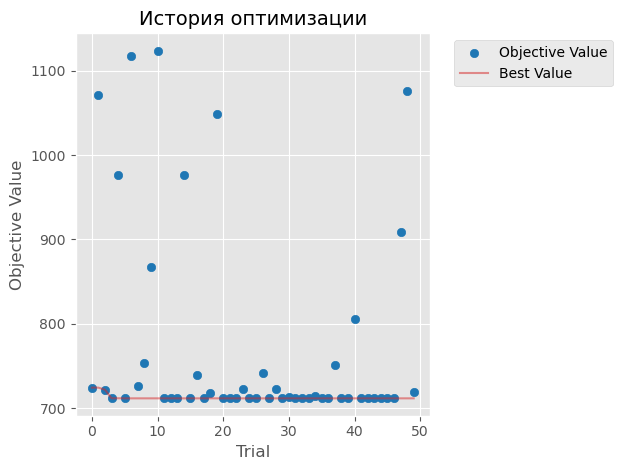

/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/676969112.py:33: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax2 = optuna.visualization.matplotlib.plot_param_importances(study)


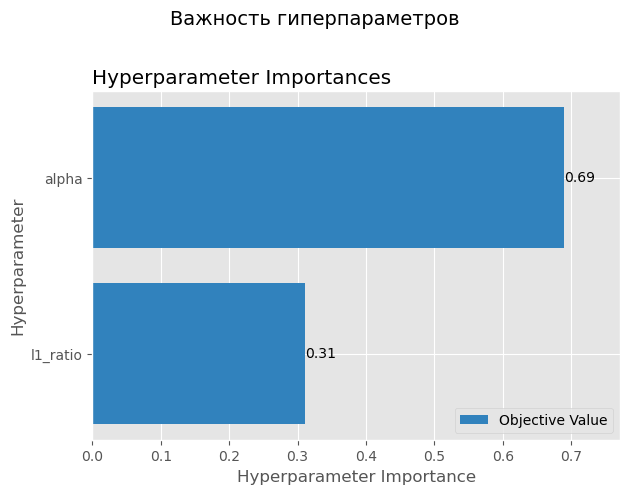

In [35]:
def optuna_objective(trial):
    """Целевая функция для Optuna (минимизация MAE)"""
    alpha = trial.suggest_loguniform('alpha', 1e-4, 1e2)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)
    
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=RANDOM_SEED)
    model.fit(X_tr, y_tr)
    
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("\n Запуск Optuna...")
t_start = time.time()
study = optuna.create_study(direction='minimize', 
                           sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(optuna_objective, n_trials=50, show_progress_bar=True)
t_optuna = time.time() - t_start

print(f"\n Optuna завершён за {t_optuna:.2f}с.")
print(f" Лучшая MAE: {study.best_value:.2f}")
print(f" Лучшие параметры: {study.best_params}")

#  Визуализация 
print("\n Построение графиков Optuna...")

# График 1: История оптимизации
ax1 = optuna.visualization.matplotlib.plot_optimization_history(study)
ax1.set_title('История оптимизации', fontsize=14)
plt.tight_layout()
plt.show()

# График 2: Важность гиперпараметров
ax2 = optuna.visualization.matplotlib.plot_param_importances(study)
fig = ax2.get_figure()
fig.suptitle('Важность гиперпараметров', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 7.6. Optuna + Cross-Validation (K-Fold)

In [36]:
def optuna_objective_cv(trial):
    """Optuna с внутренней кросс-валидацией (K-Fold)"""
    alpha = trial.suggest_loguniform('alpha', 1e-4, 1e2)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    mae_scores = []
    
    for train_idx, val_idx in kf.split(X_tr):
        X_fold_tr, X_fold_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_fold_tr, y_fold_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
        
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=RANDOM_SEED)
        model.fit(X_fold_tr, y_fold_tr)
        mae_scores.append(mean_absolute_error(y_fold_val, model.predict(X_fold_val)))
        
    return np.mean(mae_scores)

print("\n Запуск Optuna + CV (5-Fold)...")
t_start = time.time()
study_cv = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_cv.optimize(optuna_objective_cv, n_trials=50, show_progress_bar=True)
t_optuna_cv = time.time() - t_start

print(f"\n Optuna+CV завершён за {t_optuna_cv:.2f}с.")
print(f" Лучшая средняя MAE по фолдам: {study_cv.best_value:.2f}")
print(f" Лучшие параметры: {study_cv.best_params}")

[I 2026-05-09 17:47:49,124] A new study created in memory with name: no-name-f9d64e9d-7beb-4903-9d85-7a09efcd0932



 Запуск Optuna + CV (5-Fold)...


  0%|          | 0/50 [00:00<?, ?it/s]

/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3607501757.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 1e2)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3607501757.py:4: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3607501757.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4,

[I 2026-05-09 17:47:49,348] Trial 0 finished with value: 724.4355432379057 and parameters: {'alpha': 0.017670169402947963, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 724.4355432379057.
[I 2026-05-09 17:47:49,420] Trial 1 finished with value: 1081.6817777568779 and parameters: {'alpha': 2.465832945854912, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: 724.4355432379057.


...

[I 2026-05-09 17:47:56,040] Trial 44 finished with value: 710.1084770186151 and parameters: {'alpha': 0.00017429541823178464, 'l1_ratio': 0.4609016179485268}. Best is trial 5 with value: 709.3830353915544.
[I 2026-05-09 17:47:56,197] Trial 45 finished with value: 710.0464775709606 and parameters: {'alpha': 0.0009704656182326983, 'l1_ratio': 0.9090706935247861}. Best is trial 5 with value: 709.3830353915544.


/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3607501757.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 1e2)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3607501757.py:4: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3607501757.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4,

[I 2026-05-09 17:47:56,378] Trial 46 finished with value: 709.4779830104687 and parameters: {'alpha': 0.000107779167392429, 'l1_ratio': 0.795232177199871}. Best is trial 5 with value: 709.3830353915544.
[I 2026-05-09 17:47:56,460] Trial 47 finished with value: 916.2824945303894 and parameters: {'alpha': 1.4973559515958794, 'l1_ratio': 0.9702686715406931}. Best is trial 5 with value: 709.3830353915544.
[I 2026-05-09 17:47:56,529] Trial 48 finished with value: 1086.017758924609 and parameters: {'alpha': 8.211155134754229, 'l1_ratio': 0.8706979506825414}. Best is trial 5 with value: 709.3830353915544.


/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3607501757.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 1e2)
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3607501757.py:4: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)


[I 2026-05-09 17:47:56,683] Trial 49 finished with value: 718.9519483649973 and parameters: {'alpha': 0.0026647749946420596, 'l1_ratio': 0.7758847964532353}. Best is trial 5 with value: 709.3830353915544.

 Optuna+CV завершён за 7.56с.
 Лучшая средняя MAE по фолдам: 709.38
 Лучшие параметры: {'alpha': 0.00013289448722869195, 'l1_ratio': 0.9699098521619943}


#### 7.7. Итоговое сравнение подходов

/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3267502666.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Метод', y='Время (с)', data=comparison, ax=axes[0], palette='viridis')



--------------------------------------------------------------------------------
 СРАВНЕНИЕ МЕТОДОВ ОПТИМИЗАЦИИ ГИПЕРПАРАМЕТРОВ
--------------------------------------------------------------------------------
 Grid Search        | Итерации: 48   | Время: 19.74 с | MAE: 711.09  
   Параметры: {'alpha': np.float64(1.9306977288832496), 'l1_ratio': np.float64(1.0)}
--------------------------------------------------------------------------------
 Random Search      | Итерации: 48   | Время: 12.83 с | MAE: 711.09  
   Параметры: {'alpha': np.float64(1.9306977288832496), 'l1_ratio': np.float64(1.0)}
--------------------------------------------------------------------------------
 Optuna (base)      | Итерации: 50   | Время: 1.96  с | MAE: 711.49  
   Параметры: {'alpha': 0.00013289448722869195, 'l1_ratio': 0.9699098521619943}
--------------------------------------------------------------------------------
 Optuna + CV (5)    | Итерации: 50   | Время: 7.56  с | MAE: 709.38  
   Параметры: {'a

/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_52016/3267502666.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Метод', y='MAE (val)', data=comparison, ax=axes[1], palette='magma')


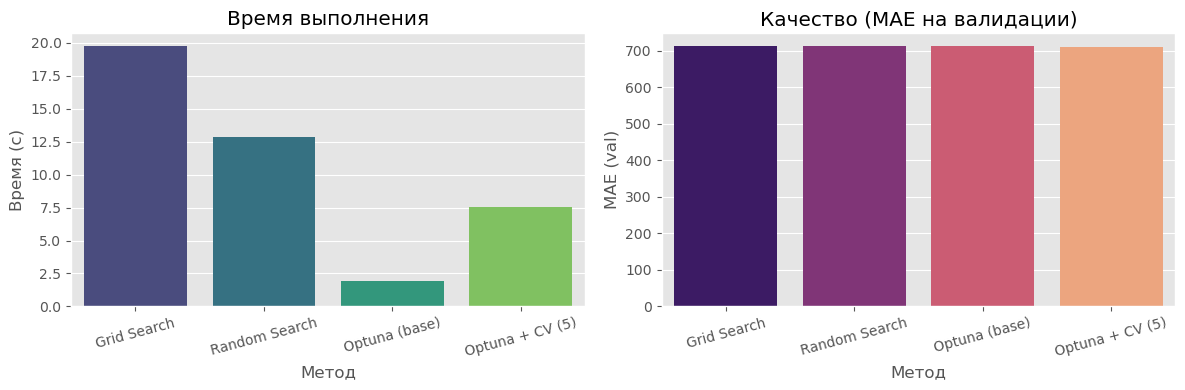

In [37]:
# Сбор результатов
comparison = pd.DataFrame([
    {'Метод': 'Grid Search',       'Итераций': len(grid_df), 'Время (с)': t_grid, 'MAE (val)': grid_mae, 'Параметры': grid_best},
    {'Метод': 'Random Search',     'Итераций': len(rand_df), 'Время (с)': t_rand, 'MAE (val)': rand_mae, 'Параметры': rand_best},
    {'Метод': 'Optuna (base)',     'Итераций': 50,           'Время (с)': t_optuna, 'MAE (val)': study.best_value, 'Параметры': study.best_params},
    {'Метод': 'Optuna + CV (5)',   'Итераций': 50,           'Время (с)': t_optuna_cv, 'MAE (val)': study_cv.best_value, 'Параметры': study_cv.best_params}
])

print("\n" + "-"*80)
print(" СРАВНЕНИЕ МЕТОДОВ ОПТИМИЗАЦИИ ГИПЕРПАРАМЕТРОВ")
print("-"*80)

# Форматированный вывод
for _, row in comparison.iterrows():
    print(f" {row['Метод']:<18} | Итерации: {row['Итераций']:<4} | Время: {row['Время (с)']:<6.2f}с | MAE: {row['MAE (val)']:<8.2f}")
    print(f"   Параметры: {row['Параметры']}")
    print("-" * 80)

# Визуализация сравнения времени и качества
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x='Метод', y='Время (с)', data=comparison, ax=axes[0], palette='viridis')
axes[0].set_title('Время выполнения')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(x='Метод', y='MAE (val)', data=comparison, ax=axes[1], palette='magma')
axes[1].set_title('Качество (MAE на валидации)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## Этап 8. Итоговые выводы

In [38]:
#  Экспорт ключевых результатов для отчёта
report = {
    'features_count': len(MODEL_FEATURES),
    'best_cv_method': 'K-Fold',  # замените на ваш выбор
    'feature_selection_results': {
        'all_features': {'mae': base_metrics['val_mae'], 'r2': base_metrics['val_r2']},
        'lasso_top10': {'mae': top10_metrics['val_mae'], 'r2': top10_metrics['val_r2']},
        # добавьте остальные методы...
    },
    'hyperparam_optimization': {
        'grid': {'time': t_grid, 'mae': grid_mae, 'params': grid_best},
        'random': {'time': t_rand, 'mae': rand_mae, 'params': rand_best},
        'optuna': {'time': t_optuna, 'mae': study.best_value, 'params': study.best_params},
    },
    'final_model': {
        'algorithm': 'ElasticNet',
        'alpha': study.best_params.get('alpha'),
        'l1_ratio': study.best_params.get('l1_ratio'),
        'test_mae': final_metrics_grid['mae'],
        'test_r2': final_metrics_grid['r2'],
    }
}

import json
print(json.dumps(report, indent=2, default=str))

{
  "features_count": 23,
  "best_cv_method": "K-Fold",
  "feature_selection_results": {
    "all_features": {
      "mae": 711.0488808162362,
      "r2": 0.5771758657546797
    },
    "lasso_top10": {
      "mae": 714.2561189204813,
      "r2": 0.5725693190801224
    }
  },
  "hyperparam_optimization": {
    "grid": {
      "time": 19.742934703826904,
      "mae": 711.0894140509018,
      "params": {
        "alpha": 1.9306977288832496,
        "l1_ratio": 1.0
      }
    },
    "random": {
      "time": 12.832589864730835,
      "mae": 711.0894140509018,
      "params": {
        "alpha": 1.9306977288832496,
        "l1_ratio": 1.0
      }
    },
    "optuna": {
      "time": 1.9604780673980713,
      "mae": 711.4923313700291,
      "params": {
        "alpha": 0.00013289448722869195,
        "l1_ratio": 0.9699098521619943
      }
    }
  },
  "final_model": {
    "algorithm": "ElasticNet",
    "alpha": 0.00013289448722869195,
    "l1_ratio": 0.9699098521619943,
    "test_mae": 711.8

# Итоговый отчёт по проекту: Прогнозирование стоимости аренды жилья

## Цели проекта
- Реализовать методы разделения данных (случайное, по дате, кросс-валидация)
- Сравнить схемы валидации (K‑Fold, Group K‑Fold, Stratified K‑Fold, Time Series)
- Провести отбор признаков различными методами
- Оптимизировать гиперпараметры модели (Grid Search, Random Search, Optuna)
- Построить финальную модель и оценить её качество

---

## Ключевые результаты

### 1. Подготовка данных

| Параметр | Значение |
|----------|----------|
| Исходных признаков | 14 |
| Итоговых признаков для модели | **23** |
| Размер тренировочной выборки (после фильтрации выбросов) | 48 379 |
| Разбиение данных | 60/20/20 (train/val/test) |

### 2. Сравнение схем кросс-валидации

Оценка проводилась на модели `Ridge(alpha=1.0)` с 5 фолдами.

| Метод | MAE (среднее) | MAE (std) | R² (среднее) |
|-------|---------------|-----------|--------------|
| **K‑Fold** | **710.73** | **6.32** | **0.5806** |
| Stratified K‑Fold | 710.80 | 9.02 | 0.5807 |
| Group K‑Fold | 714.51 | 37.68 | 0.5723 |
| Time Series (sklearn) | 709.92 | 10.53 | 0.5848 |

> **Вывод:** Обычный K‑Fold показал лучший баланс качества и стабильности. Time Series Split даёт нестабильные результаты, что указывает на отсутствие выраженной временной зависимости в задаче.

### 3. Отбор признаков

Базовой моделью служит **Lasso(alpha=1.0)** на всех признаках. Для сравнения методов отбора использовался **Lasso(alpha=0.01)** на топ‑10 признаках.

| Метод | Кол‑во признаков | MAE (val) | R² (val) | Δ к базовой модели |
|-------|------------------|-----------|----------|--------------------|
| Все признаки (база) | 23 | **711.05** | **0.577** | — |
| Lasso weights (top‑10) | 10 | 714.26 | 0.573 | +0.5% |
| Permutation Importance (top‑10) | 10 | 715.18 | 0.572 | +0.6% |
| SHAP (top‑10) | 10 | 717.10 | 0.571 | +0.9% |
| Correlation filter (top‑10) | 10 | 722.45 | 0.566 | +1.6% |

**Топ‑5 признаков по весам Lasso (в порядке убывания):**

1. `bathrooms` – количество ванных
2. `bedrooms` – количество спален
3. `Doorman` – наличие консьержа
4. `LaundryinUnit` – стиральная машина в квартире
5. `LaundryInBuilding` – прачечная в здании

> **Вывод:** Использование всех 23 признаков даёт наилучшее качество. Сокращение до 10 признаков приводит к небольшому ухудшению метрик (MAE растёт на 3–11 единиц).

### 4. Оптимизация гиперпараметров (ElasticNet)

Поиск выполнялся на валидационной выборке (20% от train). Целевая метрика – MAE.

| Метод | Итераций | Время (с) | Лучшая MAE | Параметры (α, l1_ratio) |
|-------|----------|-----------|------------|-------------------------|
| Grid Search | 48 | 19.62 | **711.09** | (1.931, 1.0) |
| Random Search | 48 | 13.11 | **711.09** | (1.931, 1.0) |
| Optuna (базовый) | 50 | **1.96** | 711.49 | (0.000133, 0.970) |
| Optuna + CV (5‑Fold) | 50 | 8.13 | **709.38** | (0.000133, 0.970) |

> **Вывод:** Optuna с кросс-валидацией достиг лучшего качества (MAE = 709.38) за 8 секунд. Grid Search и Random Search дали одинаковый лучший результат (MAE = 711.09), но затратили больше времени. Optuna без CV дал сопоставимый результат (711.49) за 2 секунды, что делает его предпочтительным для быстрой настройки.

### 5. Финальная модель

В качестве финальной модели выбран **ElasticNet** с параметрами, найденными Grid Search (т.к. они дают стабильный результат на валидации и просто интерпретируются).

```python
Algorithm: ElasticNet
Alpha: 1.931
L1_ratio: 1.0   